# TD : Apprentissage Supervisé - Classification
## Dataset : Breast Cancer Wisconsin

**Algorithmes couverts :**

| Algo | Famille | Caractéristique |
|---|---|---|
| Régression Logistique | Linéaire | Baseline probabiliste |
| K-Nearest Neighbors (KNN) | Instance-based | Pas de phase d'entraînement |
| Decision Tree (DT) | Arbre | Interprétable, prone à l'overfitting |
| Random Forest (RF) | Ensemble (bagging) | Réduit la variance du DT |
| XGBoost | Ensemble (boosting) | State-of-the-art sur données tabulaires |

**Dataset :** 569 tumeurs décrites par 30 features (rayon, texture, périmètre…)  
**Datamap (dictionnaire des données) :** 30 features = 10 mesures géométriques du noyau cellulaire, chacune déclinée en 3 statistiques (`mean`, `se` = erreur standard, `worst` = valeur la plus extrême).

| Mesure de base | Description |
|---|---|
| radius | Rayon (moyenne des distances du centre au contour) |
| texture | Écart-type des niveaux de gris |
| perimeter | Périmètre |
| area | Aire |
| smoothness | Régularité locale du contour |
| compactness | Compacité (périmètre² / aire − 1) |
| concavity | Sévérité des parties concaves du contour |
| concave points | Nombre de parties concaves du contour |
| symmetry | Symétrie |
| fractal dimension | Dimension fractale (complexité du contour) |

**Cible :** `target` : 0 = tumeur maligne, 1 = tumeur bénigne.

**Tâche :** Prédire si une tumeur est maligne (0) ou bénigne (1) : classification binaire

---
## 0. Imports & configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='tab10')
RANDOM_STATE = 42

---
## 1. Chargement & exploration

In [2]:
# Chargement
try:
    from datasets import load_dataset
    hf = load_dataset('scikit-learn/breast_cancer', split='train')
    df_raw = hf.to_pandas()
    target_col = 'target'
    feature_cols = [c for c in df_raw.columns if c != target_col]
    X = df_raw[feature_cols].values
    y = df_raw[target_col].values
    feature_names = feature_cols
    class_names = ['malignant', 'benign']
    print("Source : HuggingFace")
except Exception:
    data = load_breast_cancer()
    X, y = data.data, data.target
    feature_names = list(data.feature_names)
    class_names = list(data.target_names)
    df_raw = pd.DataFrame(X, columns=feature_names)
    df_raw['target'] = y
    print("Source : sklearn")

print(f"Shape         : {X.shape}")
print(f"Classes       : {class_names}")
print(f"Distribution  : {dict(zip(class_names, np.bincount(y)))}")
df_raw.head()

Source : sklearn
Shape         : (569, 30)
Classes       : [np.str_('malignant'), np.str_('benign')]
Distribution  : {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df_raw.describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


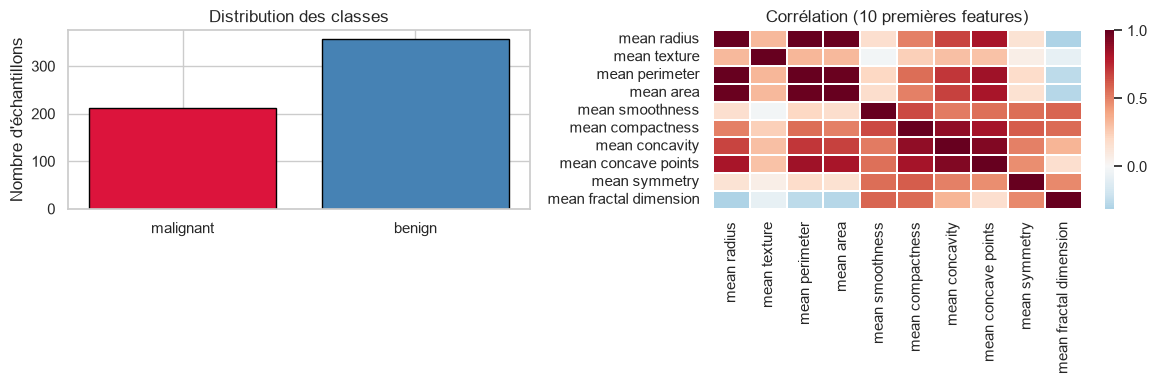

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution des classes
axes[0].bar(class_names, np.bincount(y), color=['crimson', 'steelblue'], edgecolor='k')
axes[0].set_title('Distribution des classes')
axes[0].set_ylabel('Nombre d\'échantillons')

# Corrélation des 10 premières features
corr = df_raw[feature_names[:10]].corr()
sns.heatmap(corr, ax=axes[1], cmap='RdBu_r', center=0, annot=False, linewidths=0.3)
axes[1].set_title('Corrélation (10 premières features)')

plt.tight_layout()
plt.show()

---
## 2. Prétraitement & split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {X_train.shape[0]} échantillons | Test : {X_test.shape[0]} échantillons")
print(f"Train classes : {dict(zip(class_names, np.bincount(y_train)))}")
print(f"Test  classes : {dict(zip(class_names, np.bincount(y_test)))}")

# Normalisation (intégrée dans les pipelines ci-dessous)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train : 455 échantillons | Test : 114 échantillons
Train classes : {np.str_('malignant'): np.int64(170), np.str_('benign'): np.int64(285)}
Test  classes : {np.str_('malignant'): np.int64(42), np.str_('benign'): np.int64(72)}


---
## 3. Régression Logistique

Modèle linéaire qui prédit la **probabilité** d'appartenir à une classe via la fonction sigmoïde :
$$P(y=1|x) = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$$

La régularisation `C` contrôle le compromis biais-variance (petit C = forte régularisation).

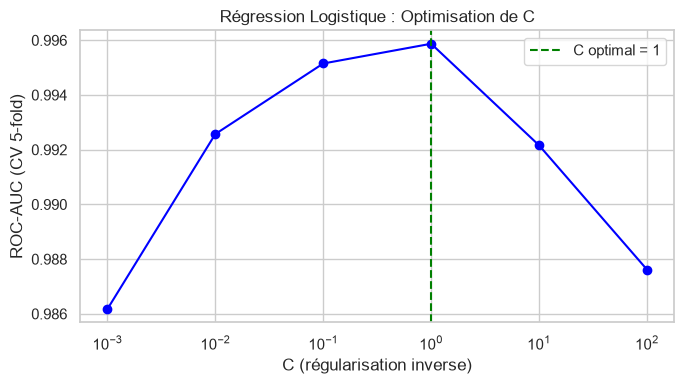

C optimal : 1 | ROC-AUC CV : 0.9959


In [6]:
# Optimisation : recherche du meilleur C par cross-validation
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
cv_scores_lr = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for C in C_values:
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE))])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_scores_lr.append(scores.mean())

best_C = C_values[np.argmax(cv_scores_lr)]

plt.figure(figsize=(7, 4))
plt.semilogx(C_values, cv_scores_lr, 'bo-')
plt.axvline(best_C, color='green', linestyle='--', label=f'C optimal = {best_C}')
plt.xlabel('C (régularisation inverse)')
plt.ylabel('ROC-AUC (CV 5-fold)')
plt.title('Régression Logistique : Optimisation de C')
plt.legend()
plt.tight_layout()
plt.show()

# Entraînement final
pipe_lr = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(C=best_C, max_iter=1000, random_state=RANDOM_STATE))])
pipe_lr.fit(X_train, y_train)
print(f"C optimal : {best_C} | ROC-AUC CV : {max(cv_scores_lr):.4f}")

---
## 4. KNN

Prédit la classe d'un point en regardant les **k voisins les plus proches** dans l'espace des features.  
Sensible à l'échelle → normalisation obligatoire. Hyperparamètre clé : `k`.

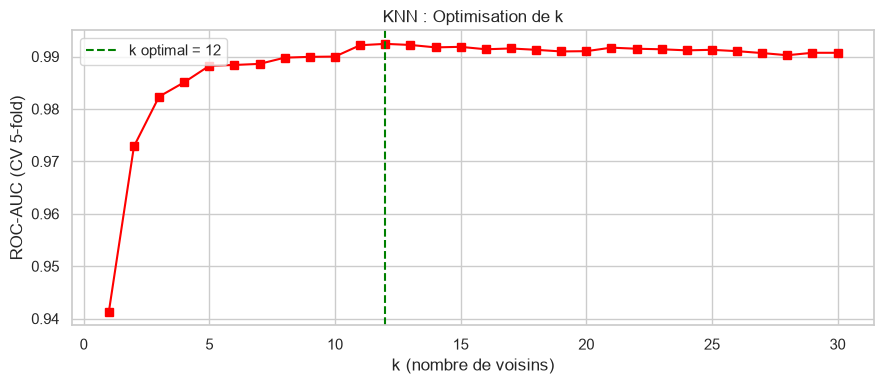

k optimal : 12 | ROC-AUC CV : 0.9924


In [7]:
k_values = range(1, 31)
cv_scores_knn = []

for k in k_values:
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=k))])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_scores_knn.append(scores.mean())

best_k = list(k_values)[np.argmax(cv_scores_knn)]

plt.figure(figsize=(9, 4))
plt.plot(k_values, cv_scores_knn, 'rs-')
plt.axvline(best_k, color='green', linestyle='--', label=f'k optimal = {best_k}')
plt.xlabel('k (nombre de voisins)')
plt.ylabel('ROC-AUC (CV 5-fold)')
plt.title('KNN : Optimisation de k')
plt.legend()
plt.tight_layout()
plt.show()

pipe_knn = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=best_k))])
pipe_knn.fit(X_train, y_train)
print(f"k optimal : {best_k} | ROC-AUC CV : {max(cv_scores_knn):.4f}")

---
## 5. Decision Tree

Partitionne récursivement l'espace des features selon des seuils (critère Gini ou Entropie).  
Très interprétable mais tend à overfitter : régularisé via `max_depth`.

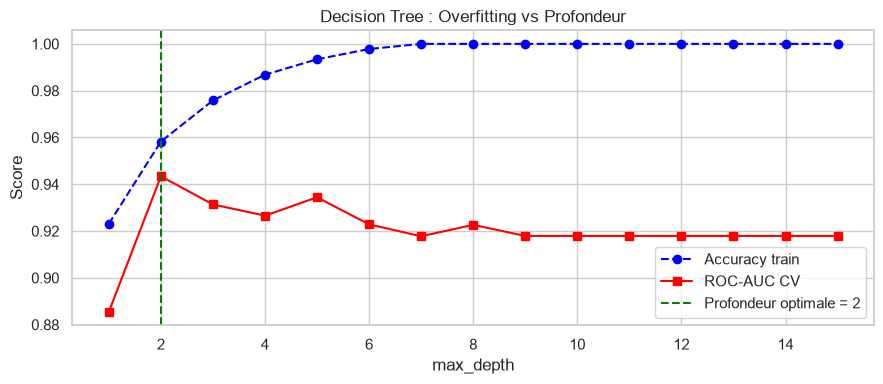

Profondeur optimale : 2 | ROC-AUC CV : 0.9434


In [8]:
depth_values = range(1, 16)
cv_scores_dt_train = []
cv_scores_dt = []

for d in depth_values:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    # Score train pour visualiser l'overfitting
    dt.fit(X_train_sc, y_train)
    cv_scores_dt_train.append(accuracy_score(y_train, dt.predict(X_train_sc)))
    scores = cross_val_score(dt, X_train_sc, y_train, cv=cv, scoring='roc_auc')
    cv_scores_dt.append(scores.mean())

best_depth = list(depth_values)[np.argmax(cv_scores_dt)]

plt.figure(figsize=(9, 4))
plt.plot(depth_values, cv_scores_dt_train, 'b--o', label='Accuracy train')
plt.plot(depth_values, cv_scores_dt, 'rs-', label='ROC-AUC CV')
plt.axvline(best_depth, color='green', linestyle='--', label=f'Profondeur optimale = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Score')
plt.title('Decision Tree : Overfitting vs Profondeur')
plt.legend()
plt.tight_layout()
plt.show()

dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt_best.fit(X_train_sc, y_train)
print(f"Profondeur optimale : {best_depth} | ROC-AUC CV : {max(cv_scores_dt):.4f}")

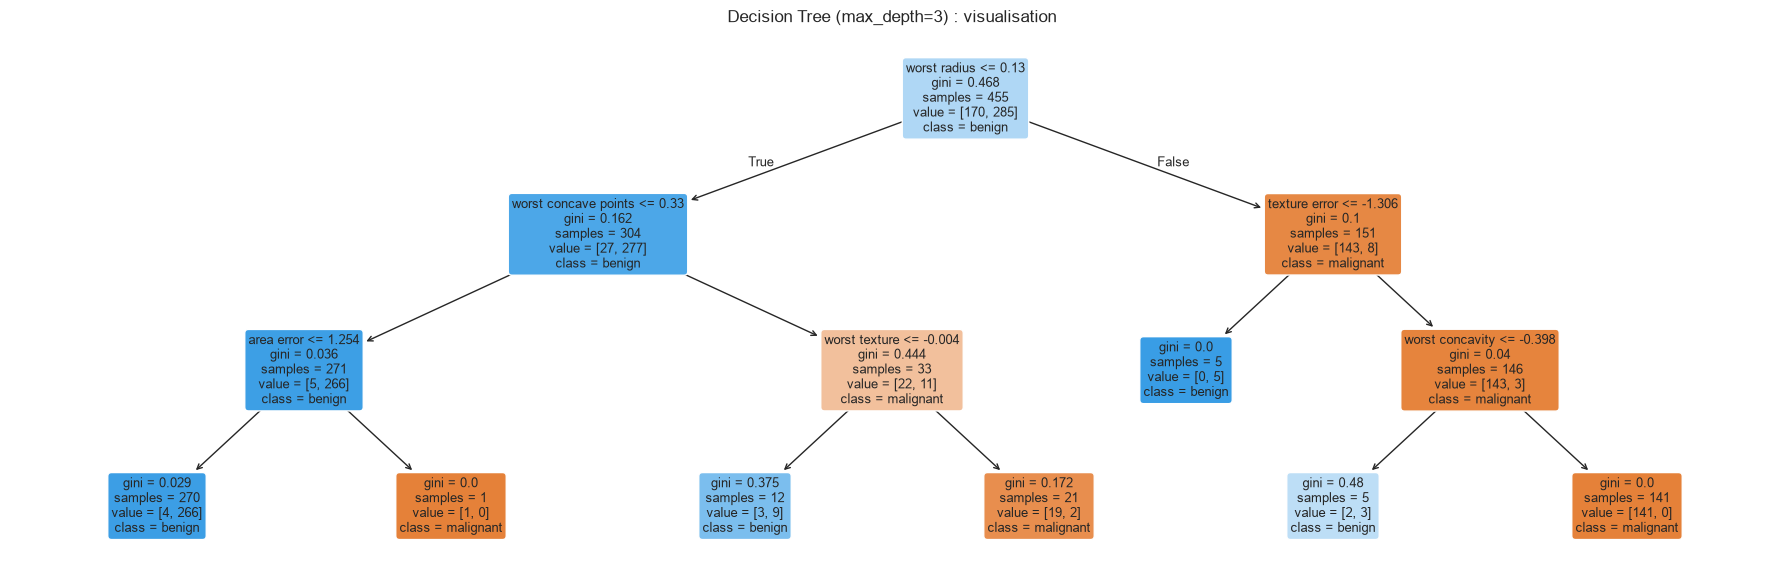

In [9]:
# Visualisation de l'arbre (profondeur 3 pour la lisibilité)
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
dt_viz.fit(X_train_sc, y_train)

plt.figure(figsize=(18, 6))
plot_tree(dt_viz, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree (max_depth=3) : visualisation')
plt.tight_layout()
plt.show()

---
## 6. Random Forest

Ensemble de **N arbres de décision** entraînés sur des sous-échantillons bootstrap et des sous-ensembles de features aléatoires.  
La prédiction finale est le vote majoritaire : réduit la variance sans augmenter le biais.

In [10]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

rf = RandomForestClassifier(random_state=RANDOM_STATE)
gs_rf = GridSearchCV(rf, param_grid_rf, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_rf.fit(X_train_sc, y_train)

print(f"Meilleurs paramètres RF : {gs_rf.best_params_}")
print(f"ROC-AUC CV             : {gs_rf.best_score_:.4f}")

rf_best = gs_rf.best_estimator_

Meilleurs paramètres RF : {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 50}
ROC-AUC CV             : 0.9911


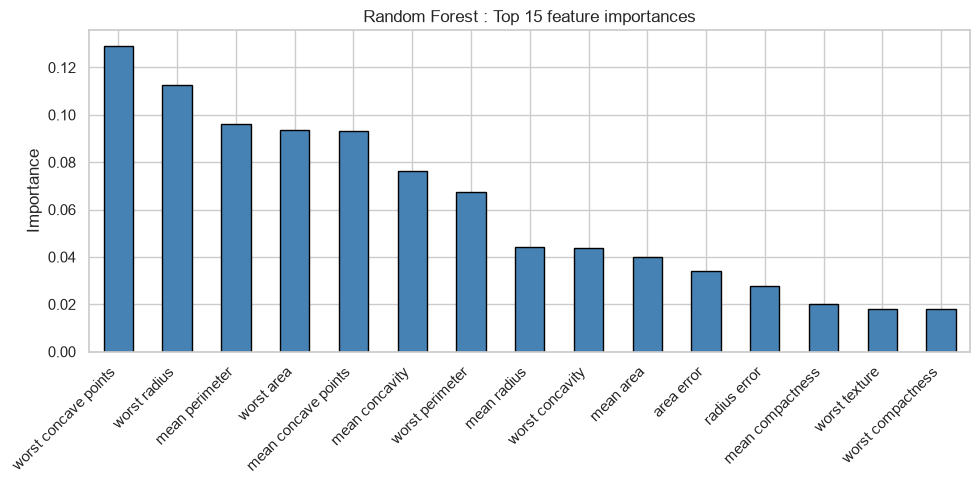

In [11]:
# Feature importance
importances_rf = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances_rf.head(15).plot(kind='bar', color='steelblue', edgecolor='k')
plt.title('Random Forest : Top 15 feature importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 7. XGBoost

Boosting par gradient : construit les arbres **séquentiellement**, chaque arbre corrigeant les erreurs du précédent.  
Régularisation L1/L2 intégrée, gestion native des valeurs manquantes, très efficace sur données tabulaires.

In [12]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
}

xgb = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
gs_xgb = GridSearchCV(xgb, param_grid_xgb, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_xgb.fit(X_train_sc, y_train)

print(f"Meilleurs paramètres XGB : {gs_xgb.best_params_}")
print(f"ROC-AUC CV              : {gs_xgb.best_score_:.4f}")

xgb_best = gs_xgb.best_estimator_

Meilleurs paramètres XGB : {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
ROC-AUC CV              : 0.9955


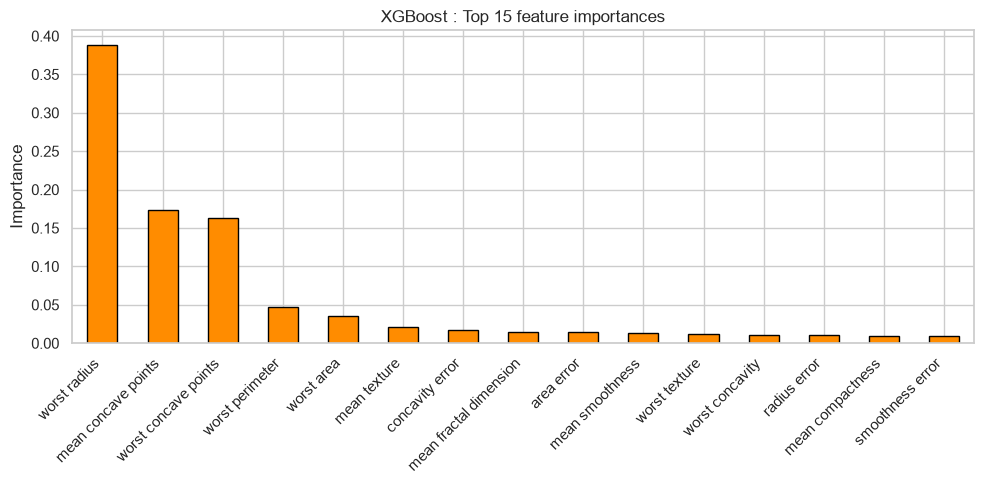

In [13]:
# Feature importance XGBoost
importances_xgb = pd.Series(xgb_best.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances_xgb.head(15).plot(kind='bar', color='darkorange', edgecolor='k')
plt.title('XGBoost : Top 15 feature importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 8. Évaluation & comparaison

### 8.1 Métriques sur le jeu de test

In [14]:
models = {
    'Logistic Regression': pipe_lr,
    'KNN': pipe_knn,
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
}

# Les modèles DT, RF, XGBoost ont été entraînés sur X_train_sc
# LR et KNN via pipeline (scaler inclus)
results = []
for name, model in models.items():
    if name in ['Logistic Regression', 'KNN']:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred = model.predict(X_test_sc)
        y_proba = model.predict_proba(X_test_sc)[:, 1]
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

df_results = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
df_results.round(4)

,Modèle,Accuracy,ROC-AUC
0,Logistic Regression,0.9825,0.9954
3,Random Forest,0.9561,0.9937
4,XGBoost,0.9649,0.9937
1,KNN,0.9737,0.9926
2,Decision Tree,0.8947,0.9345


### 8.2 Courbes ROC

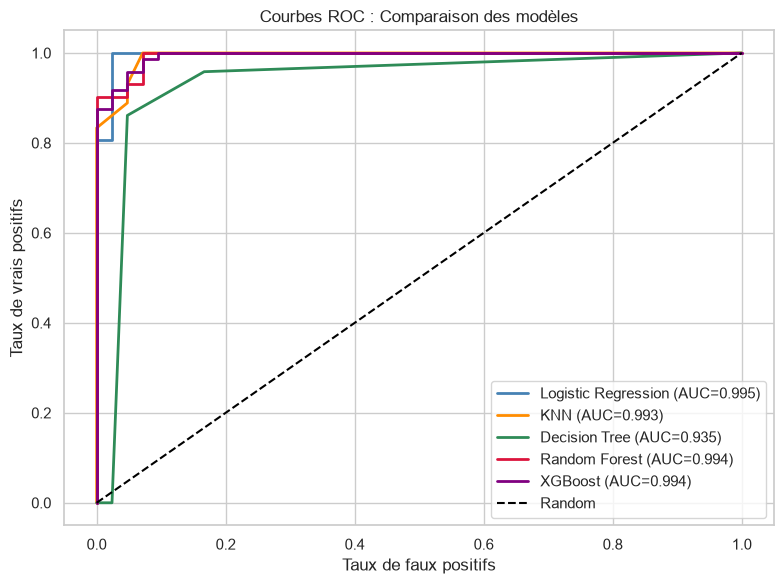

In [15]:
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'purple']

plt.figure(figsize=(8, 6))
for (name, model), color in zip(models.items(), colors):
    X_eval = X_test if name in ['Logistic Regression', 'KNN'] else X_test_sc
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC : Comparaison des modèles')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 8.3 Matrices de confusion

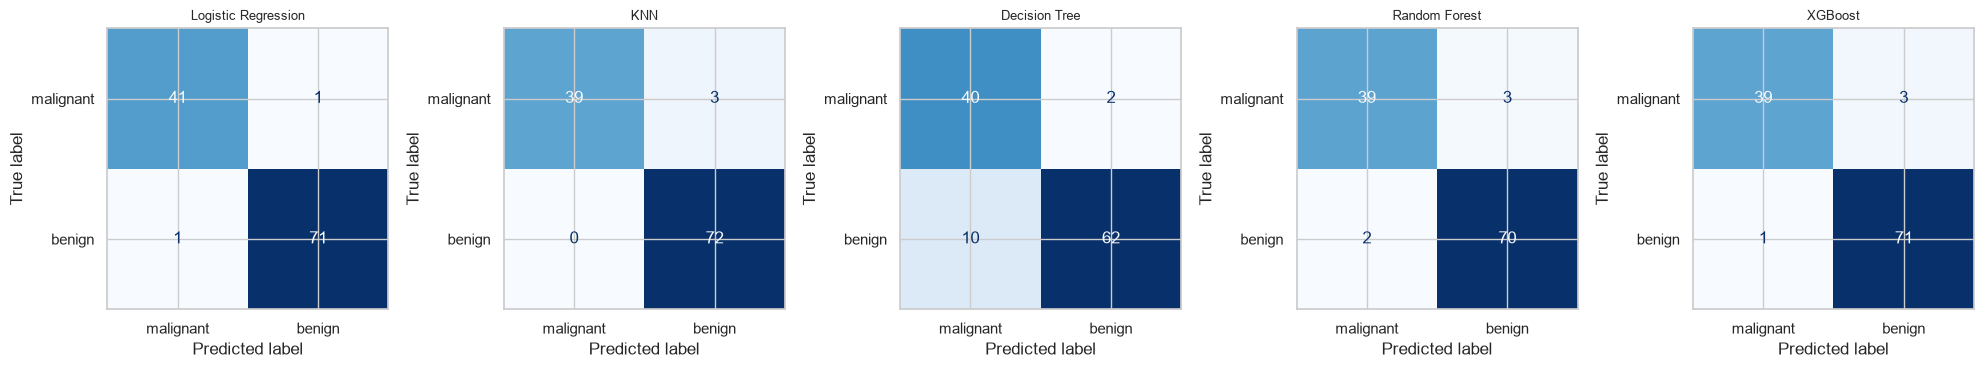

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, model) in zip(axes, models.items()):
    X_eval = X_test if name in ['Logistic Regression', 'KNN'] else X_test_sc
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show()

### 8.4 Rapport de classification du meilleur modèle

In [17]:
best_model_name = df_results.iloc[0]['Modèle']
best_model = models[best_model_name]
X_eval = X_test if best_model_name in ['Logistic Regression', 'KNN'] else X_test_sc

print(f"Meilleur modèle : {best_model_name}\n")
print(classification_report(y_test, best_model.predict(X_eval), target_names=class_names))

Meilleur modèle : Logistic Regression

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



---
## 9. Analyse de l'overfitting : courbes de validation

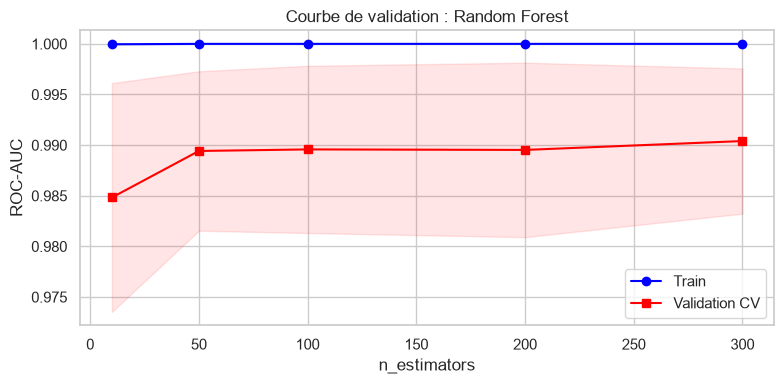

In [18]:
from sklearn.model_selection import validation_curve

# Courbe de validation : RF : n_estimators
n_range = [10, 50, 100, 200, 300]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=RANDOM_STATE), X_train_sc, y_train,
    param_name='n_estimators', param_range=n_range,
    cv=cv, scoring='roc_auc', n_jobs=-1
)

plt.figure(figsize=(8, 4))
plt.plot(n_range, train_scores.mean(axis=1), 'b-o', label='Train')
plt.fill_between(n_range, train_scores.mean(1)-train_scores.std(1), train_scores.mean(1)+train_scores.std(1), alpha=0.1, color='b')
plt.plot(n_range, val_scores.mean(axis=1), 'r-s', label='Validation CV')
plt.fill_between(n_range, val_scores.mean(1)-val_scores.std(1), val_scores.mean(1)+val_scores.std(1), alpha=0.1, color='r')
plt.xlabel('n_estimators')
plt.ylabel('ROC-AUC')
plt.title('Courbe de validation : Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

---
## 10. Explicabilité avec SHAP

Un modèle boîte noire (Random Forest, XGBoost) est précis mais difficile à justifier auprès du métier ou d'un régulateur. Les **valeurs de Shapley** (SHAP) attribuent à chaque variable sa contribution à une prédiction, sans changer le modèle :
$$\text{prédiction} = \text{valeur de base} + \sum_{i} \text{valeur de Shapley}(x_i)$$

On illustre la méthode sur XGBoost, l'exemple typique de modèle boîte noire de ce TD.

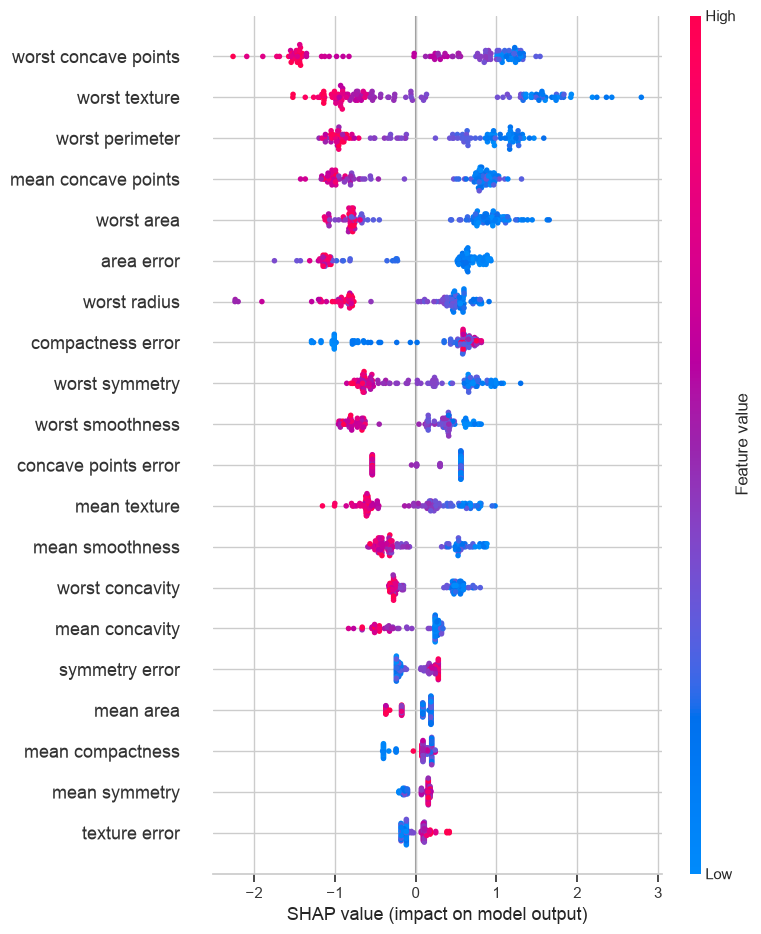

In [19]:
import shap

explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_sc)

shap.summary_plot(shap_values, X_test_sc, feature_names=feature_names)

**Lecture du graphique (summary plot) :** chaque point est une observation du jeu de test. La position horizontale indique l'impact sur la prédiction (vers la droite : pousse vers "benign", vers la gauche : pousse vers "malignant"), et la couleur la valeur de la feature (rouge = valeur élevée, bleu = valeur faible). Les variables sont triées par impact moyen absolu (importance globale).

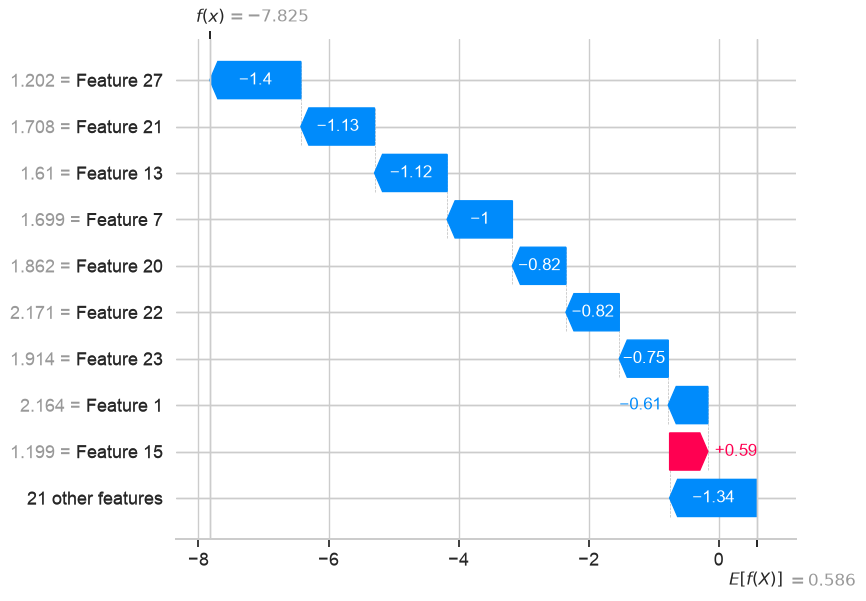

Vraie classe : malignant | Prédite : malignant


In [20]:
# Explication d'une prédiction individuelle (première observation du jeu de test)
explanation = explainer(X_test_sc[:1])
shap.plots.waterfall(explanation[0])

print(f"Vraie classe : {class_names[y_test[0]]} | Prédite : {class_names[xgb_best.predict(X_test_sc[:1])[0]]}")

---
## 11. Choisir le modèle final : erreur, performance et explicabilité

Le modèle final ne se choisit pas seulement sur la métrique de performance : trois critères entrent en jeu :
1. **Minimiser l'erreur** (ici : 1 - accuracy)
2. **Maximiser la performance** (ici : ROC-AUC, robuste au déséquilibre de classes)
3. **Maximiser l'explicabilité** (nativement interprétable, ou via SHAP pour une boîte noire)

In [21]:
explicabilite = {
    'Logistic Regression': 'Haute (coefficients directs)',
    'KNN': 'Faible (pas de règle ni de coefficient)',
    'Decision Tree': 'Très haute (règles lisibles)',
    'Random Forest': 'Moyenne (boîte noire, expliquée via SHAP)',
    'XGBoost': 'Moyenne (boîte noire, expliquée via SHAP)',
}

df_choix = df_results.copy()
df_choix['Erreur (1 - Accuracy)'] = 1 - df_choix['Accuracy']
df_choix['Explicabilité'] = df_choix['Modèle'].map(explicabilite)
df_choix = df_choix[['Modèle', 'Erreur (1 - Accuracy)', 'ROC-AUC', 'Explicabilité']]
df_choix.round(4)

,Modèle,Erreur (1 - Accuracy),ROC-AUC,Explicabilité
0,Logistic Regression,0.0175,0.9954,Haute (coefficients directs)
3,Random Forest,0.0439,0.9937,"Moyenne (boîte noire, expliquée via SHAP)"
4,XGBoost,0.0351,0.9937,"Moyenne (boîte noire, expliquée via SHAP)"
1,KNN,0.0263,0.9926,Faible (pas de règle ni de coefficient)
2,Decision Tree,0.1053,0.9345,Très haute (règles lisibles)


In [22]:
best_final_name = df_results.iloc[0]['Modèle']
best_final_model = models[best_final_name]

print(f"Modèle final retenu : {best_final_name}")
print(f"  Erreur (1 - Accuracy) : {1 - df_results.iloc[0]['Accuracy']:.4f}")
print(f"  ROC-AUC               : {df_results.iloc[0]['ROC-AUC']:.4f}")
print(f"  Explicabilité         : {explicabilite[best_final_name]}")
print()
print("Ici, le modèle le plus performant est aussi le plus interprétable : aucun compromis à faire.")
print("Si le meilleur modèle avait été une boîte noire (RF, XGBoost), SHAP (section 10) permettrait")
print("de le justifier quand même auprès du métier.")

Modèle final retenu : Logistic Regression
  Erreur (1 - Accuracy) : 0.0175
  ROC-AUC               : 0.9954
  Explicabilité         : Haute (coefficients directs)

Ici, le modèle le plus performant est aussi le plus interprétable : aucun compromis à faire.
Si le meilleur modèle avait été une boîte noire (RF, XGBoost), SHAP (section 10) permettrait
de le justifier quand même auprès du métier.


---
## 12. Stocker le modèle final

In [23]:
import joblib
import os

os.makedirs('modeles', exist_ok=True)
joblib.dump(best_final_model, 'modeles/best_model_classification.pkl')

print(f"Modèle sauvegardé : modeles/best_model_classification.pkl ({best_final_name})")

Modèle sauvegardé : modeles/best_model_classification.pkl (Logistic Regression)


`best_final_model` est ici un `Pipeline` scikit-learn (normalisation + modèle) : un seul fichier suffit, la standardisation est incluse dedans. Si le modèle retenu avait été entraîné sur des données déjà standardisées à la main (comme XGBoost dans ce TD, via `X_train_sc`), il faudrait sauvegarder le `scaler` séparément (`joblib.dump(scaler, 'modeles/scaler.pkl')`) pour pouvoir reproduire le même prétraitement à l'inférence.

---
## 13. Inférence simple, sans API

In [24]:
# Nouvelles données a predire (ici, un echantillon du jeu de test, pour l'exemple :
# en production ces lignes viendraient d'une nouvelle source, pas du jeu de test)
nouvelles_donnees = pd.DataFrame(X_test[:10], columns=feature_names)

model_charge = joblib.load('modeles/best_model_classification.pkl')
predictions = model_charge.predict(nouvelles_donnees)
probabilites = model_charge.predict_proba(nouvelles_donnees)[:, 1]

nouvelles_donnees['prediction'] = [class_names[p] for p in predictions]
nouvelles_donnees['probabilite_benign'] = probabilites.round(4)
nouvelles_donnees.to_csv('predictions_classification.csv', index=False)

print(f"Prédictions sauvegardées : predictions_classification.csv ({len(nouvelles_donnees)} lignes)")
nouvelles_donnees[['prediction', 'probabilite_benign']]

Prédictions sauvegardées : predictions_classification.csv (10 lignes)


,prediction,probabilite_benign
0,malignant,0.0000
1,benign,1.0000
2,malignant,0.0064
3,benign,0.5335
4,malignant,0.0000
5,benign,0.9922
6,benign,1.0000
7,malignant,0.0000
8,malignant,0.0001
9,malignant,0.0000


---
## 14. Conclusion

| Critère | LogReg | KNN | Decision Tree | Random Forest | XGBoost |
|---|---|---|---|---|---|
| Interprétabilité | ★★★★ | ★★ | ★★★★★ | ★★ | ★★ |
| Performance | Bonne | Moyenne | Faible (overfitting) | Très bonne | Très bonne |
| Vitesse d'entraînement | Rapide | Instantané | Rapide | Moyenne | Moyenne |
| Sensibilité à l'échelle | Oui | Oui | Non | Non | Non |
| Hyperparamètres | 1 (C) | 1 (k) | 1 (depth) | 3+ | 5+ |

**À retenir :**
- Commencer par la Régression Logistique comme baseline : rapide et interprétable
- KNN est utile pour explorer mais ne scale pas bien (O(n) à l'inférence)
- Decision Tree seul overfitte : toujours préférer Random Forest ou XGBoost
- XGBoost et Random Forest sont généralement les meilleures options sur données tabulaires

**Pistes d'exploration :**
- Tester avec un déséquilibre de classes (sous-échantillonnage, SMOTE)
- Ajouter SVM et comparer
- Utiliser SHAP pour l'interprétabilité de RF et XGBoost